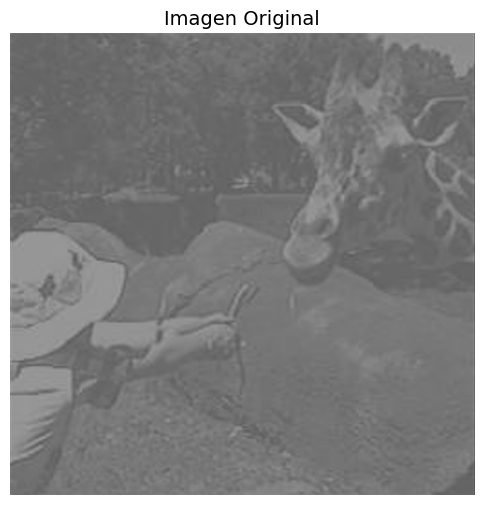

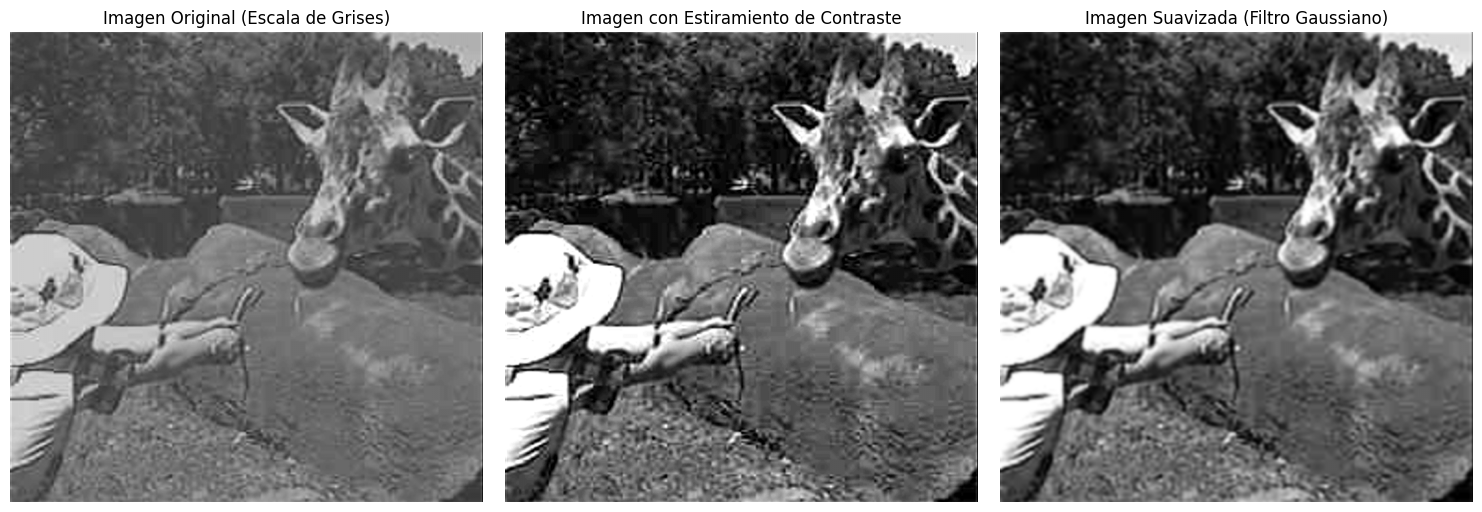

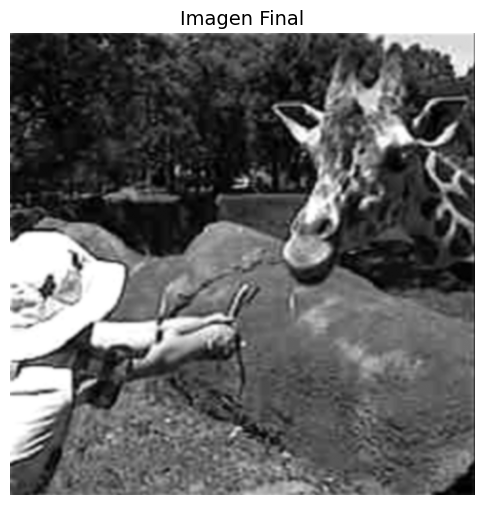

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import io, exposure, color, filters

# Cargar la imagen
lena = io.imread('jirafa.png')


# Mostramos la imagen original
plt.figure(figsize=(6, 6))
plt.imshow(lena)
plt.title("Imagen Original", fontsize=14)
plt.axis('off')
plt.show()


# Verificar si la imagen tiene 4 canales (RGBA)
if lena.shape[2] == 4:         # Si la imagen tiene un canal alfa
    lena_rgb = lena[:, :, :3]  # Eliminar el canal alfa
else:
    lena_rgb = lena            # Si no tiene canal alfa, la imagen ya está en RGB



# Convertir la imagen a escala de grises
lena_gray = color.rgb2gray(lena_rgb)


# Realizar el estiramiento de contraste
lowlim, uplim = np.percentile(lena_gray, (2, 95))    # Se ajustan los niveles
lena_rescale = exposure.rescale_intensity(lena_gray, in_range=(lowlim, uplim))


# Aplicar el filtro Gaussiano para suavizar la imagen
lena_smoothed = filters.gaussian(lena_rescale, sigma=1.5)  # Se ajusta sigma


# Crear subgráficos
f, (ax0, ax1, ax2) = plt.subplots(ncols=3, figsize=(15, 5))
# Mostrar la imagen original en escala de grises
ax0.imshow(lena_gray, cmap='gray')
ax0.set_title("Imagen Original (Escala de Grises)")
ax0.axis('off')  # Eliminar los ejes
# Mostrar la imagen con estiramiento de contraste
ax1.imshow(lena_rescale, cmap='gray')
ax1.set_title("Imagen con Estiramiento de Contraste")
ax1.axis('off')  # Eliminar los ejes
# Mostrar la imagen suavizada con el filtro Gaussiano
ax2.imshow(lena_smoothed, cmap='gray')
ax2.set_title("Imagen Suavizada (Filtro Gaussiano)")
ax2.axis('off')  # Eliminar los ejes
# Ajustar el diseño y mostrar la figura
plt.tight_layout()
plt.show()

# Mostramos la imagen original
plt.figure(figsize=(6, 6))
plt.imshow(lena_smoothed, cmap='gray')
plt.title("Imagen Final", fontsize=14)
plt.axis('off')
plt.show()